In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('housing.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [5]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [6]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

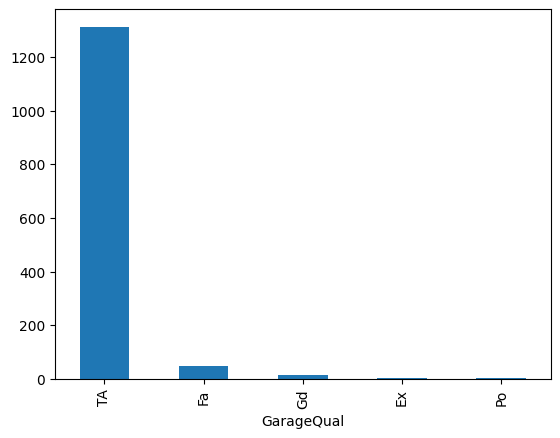

In [7]:
df['GarageQual'].value_counts().plot(kind='bar')#dekh rahe hai kaunse values missing hai column me 

In [8]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

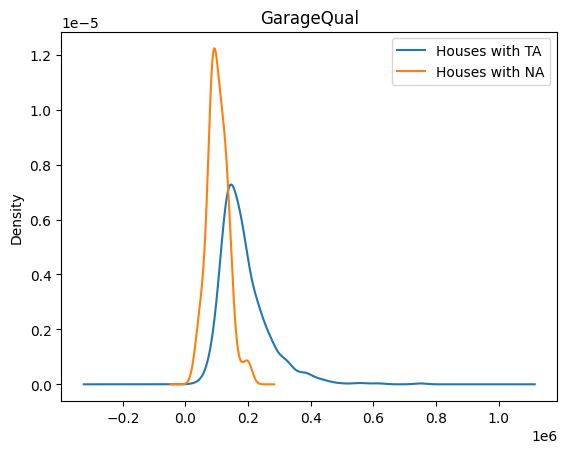

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde')
lines,labels=ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines,labels,loc='best')
plt.title('GarageQual')

In [10]:
##humne missing vaues aur mode jo ki TA hai use compare kiya aur dikha missing valuues bichme bht jyada hai

In [11]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [12]:
df['GarageQual'].fillna('TA',inplace=True)#filling missing values with TA

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21496\3354766483.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA',inplace=True)#filling missing values with TA


<Axes: xlabel='GarageQual'>

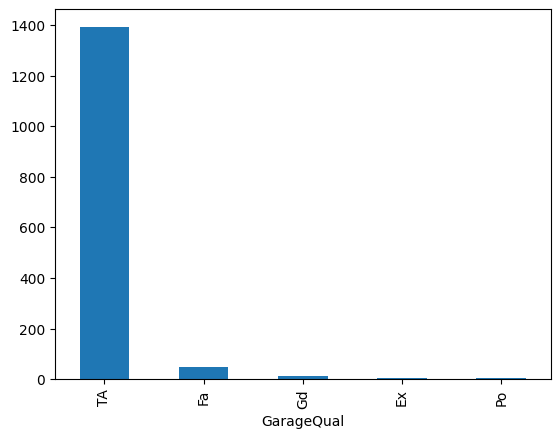

In [13]:
df['GarageQual'].value_counts().plot(kind='bar')

<Axes: ylabel='Density'>

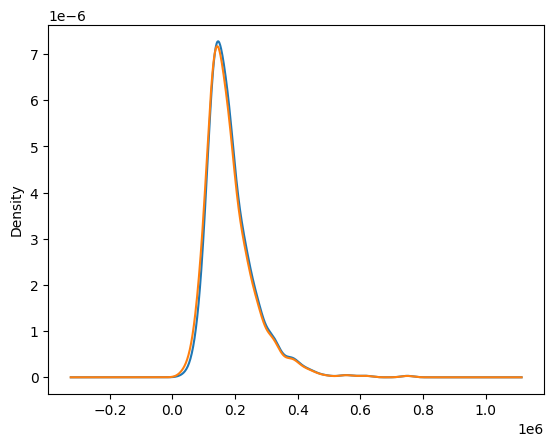

In [14]:
temp.plot(kind='kde')#original before filling missing vaues with TA
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde')#after filling missing values with TA

<Axes: xlabel='FireplaceQu'>

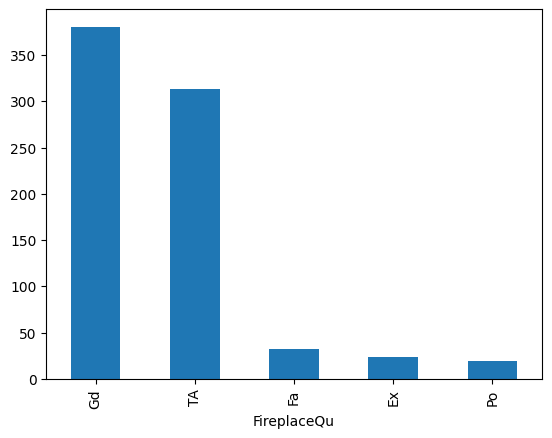

In [15]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [16]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

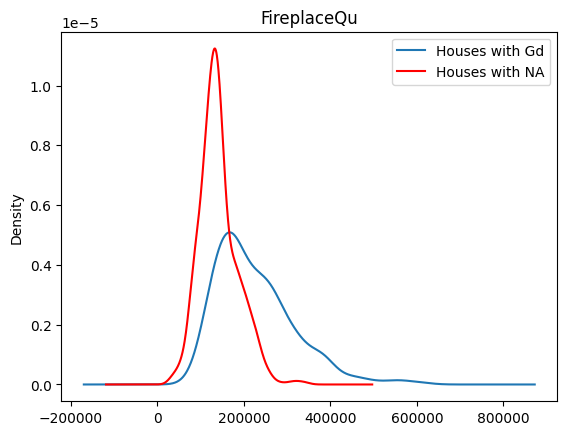

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [18]:
#same comparision kiya jo pahle wale me kiya tha

In [19]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [20]:
df['FireplaceQu'].fillna('Gd',inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_21496\891419280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd',inplace=True)


<Axes: xlabel='FireplaceQu'>

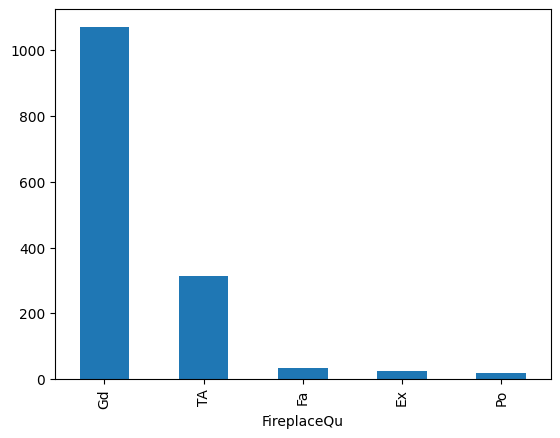

In [21]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [22]:
#aap dekh sakte hai gd ki value badh gyi hai kyuki missing values bhi gd se bhar di

Text(0.5, 1.0, 'FireplaceQu')

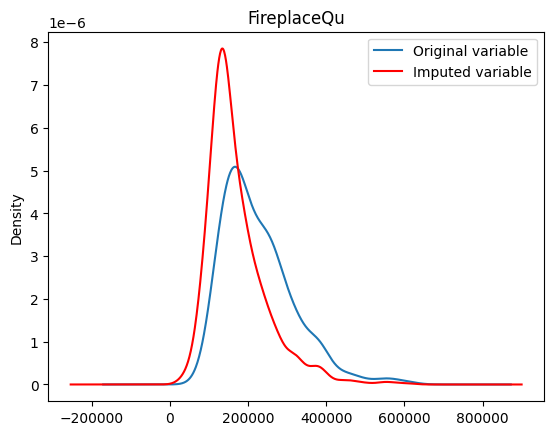

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

In [24]:
#distributin is still not same because there was too much missing values and your mode catagory which was Gd was not dominating
#so here,most frequent techique should not be used 

# using Sklearn

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [26]:
from sklearn.impute import SimpleImputer

In [27]:
imputer= SimpleImputer(strategy='most_frequent')

In [28]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

D:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [29]:
imputer.statistics_#gd is most frequent category for first one and TA is a most frequent category for second one

array(['Gd', 'TA'], dtype=object)